# Germany and EU Tourism Competitiveness Analysis
## 05 - Germany–EU Benchmark

### Purpose

This notebook evaluates Germany's international tourism performance relative to other EU27 destinations.

The objective is to move beyond Germany's standalone performance and determine where Germany is competitively strong, where measurable gaps exist, and which EU destinations provide useful benchmarks.

The analysis focuses on:

- Germany's position in EU27 international tourist arrivals
- Germany's position in EU27 international overnight stays
- changes in Germany's competitive ranking over time
- average length of stay relative to EU27 destinations
- the size of Germany's length-of-stay gap
- comparison with relevant EU tourism competitors
- identification of competitive strengths, weaknesses, and benchmarking opportunities

Only country-year observations with sufficient comparable data will be used for rankings and benchmark calculations.

Results in this notebook are descriptive competitive benchmarks. They should not be interpreted as causal estimates or forecasts.

### Benchmark Questions

This notebook addresses the following questions:

**BQ1. International Arrivals**  
How does Germany rank among EU27 destinations in international tourist arrivals?

**BQ2. International Overnight Stays**  
How does Germany rank among EU27 destinations in international overnight stays?

**BQ3. Competitive Position Over Time**  
Has Germany's EU27 competitive position changed between 2021 and 2025?

**BQ4. Average Length of Stay**  
How does Germany's international average length of stay compare with other EU27 destinations?

**BQ5. Competitive Gap**  
How large is Germany's length-of-stay gap relative to relevant EU benchmarks?

**BQ6. Competitor Benchmarking**  
Which EU destinations provide the most useful comparisons for Germany based on tourism scale and stay duration?

**BQ7. Strategic Position**  
What do the EU27 benchmarks reveal about Germany's principal tourism strengths and competitive gaps?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

print(
    "Germany-EU benchmark libraries "
    "imported successfully."
)

Germany-EU benchmark libraries imported successfully.


In [2]:
project_root = Path.cwd().parent

clean_dir = (
    project_root
    / "data"
    / "clean"
)

processed_dir = (
    project_root
    / "data"
    / "processed"
)

figures_dir = (
    project_root
    / "figures"
)

print(
    f"Project root: {project_root}"
)

print(
    f"Clean data: {clean_dir}"
)

print(
    f"Processed data: {processed_dir}"
)

print(
    f"Figures: {figures_dir}"
)

Project root: /Users/jannoelvero/Documents/germany_eu_tourism_analysis
Clean data: /Users/jannoelvero/Documents/germany_eu_tourism_analysis/data/clean
Processed data: /Users/jannoelvero/Documents/germany_eu_tourism_analysis/data/processed
Figures: /Users/jannoelvero/Documents/germany_eu_tourism_analysis/figures


In [3]:
sorted(
    file.name
    for file in clean_dir.glob("*.csv")
)

['eu27_country_reference_clean.csv',
 'eu27_foreign_arrivals_monthly_clean.csv',
 'eu27_foreign_nights_monthly_clean.csv',
 'germany_foreign_arrivals_monthly_clean.csv',
 'germany_foreign_nights_monthly_clean.csv',
 'germany_source_market_arrivals_annual_clean.csv',
 'germany_source_market_nights_annual_clean.csv',
 'germany_travel_bop_annual_clean.csv',
 'source_market_reference_clean.csv']

In [4]:
eu_arrivals = pd.read_csv(
    clean_dir
    / "eu27_foreign_arrivals_monthly_clean.csv"
)

eu_nights = pd.read_csv(
    clean_dir
    / "eu27_foreign_nights_monthly_clean.csv"
)

print(
    f"EU27 arrivals shape: "
    f"{eu_arrivals.shape}"
)

print(
    f"EU27 nights shape: "
    f"{eu_nights.shape}"
)

print(
    "\nArrivals columns:"
)
print(
    eu_arrivals.columns.tolist()
)

print(
    "\nNights columns:"
)
print(
    eu_nights.columns.tolist()
)

EU27 arrivals shape: (1809, 14)
EU27 nights shape: (1809, 14)

Arrivals columns:
['country_code', 'country', 'period', 'foreign_arrivals', 'status', 'year', 'month', 'value_available', 'is_estimated', 'is_low_reliability', 'is_confidential', 'date', 'months_available', 'complete_12_month_year']

Nights columns:
['country_code', 'country', 'period', 'foreign_nights', 'status', 'year', 'month', 'value_available', 'is_estimated', 'is_low_reliability', 'is_confidential', 'date', 'months_available', 'complete_12_month_year']


In [5]:
print("EU27 arrivals:")
display(
    eu_arrivals.head()
)

print("\nEU27 nights:")
display(
    eu_nights.head()
)

EU27 arrivals:


,country_code,country,period,foreign_arrivals,status,year,month,value_available,is_estimated,is_low_reliability,is_confidential,date,months_available,complete_12_month_year
0,AT,Austria,2021-01,39058.0,NaN,2021,1,True,NaN,NaN,False,2021-01-01,12,True
1,AT,Austria,2021-02,43690.0,NaN,2021,2,True,NaN,NaN,False,2021-02-01,12,True
2,AT,Austria,2021-03,54888.0,NaN,2021,3,True,NaN,NaN,False,2021-03-01,12,True
3,AT,Austria,2021-04,57536.0,NaN,2021,4,True,NaN,NaN,False,2021-04-01,12,True
4,AT,Austria,2021-05,312967.0,NaN,2021,5,True,NaN,NaN,False,2021-05-01,12,True



EU27 nights:


,country_code,country,period,foreign_nights,status,year,month,value_available,is_estimated,is_low_reliability,is_confidential,date,months_available,complete_12_month_year
0,AT,Austria,2021-01,148315.0,NaN,2021,1,True,NaN,NaN,False,2021-01-01,12,True
1,AT,Austria,2021-02,172759.0,NaN,2021,2,True,NaN,NaN,False,2021-02-01,12,True
2,AT,Austria,2021-03,207381.0,NaN,2021,3,True,NaN,NaN,False,2021-03-01,12,True
3,AT,Austria,2021-04,200806.0,NaN,2021,4,True,NaN,NaN,False,2021-04-01,12,True
4,AT,Austria,2021-05,994223.0,NaN,2021,5,True,NaN,NaN,False,2021-05-01,12,True


In [6]:
print("Arrivals year coverage:")
print(
    eu_arrivals.groupby("year")[
        "country_code"
    ].nunique()
)

print(
    "\nNights year coverage:"
)

print(
    eu_nights.groupby("year")[
        "country_code"
    ].nunique()
)

Arrivals year coverage:
year
2021    27
2022    27
2023    27
2024    27
2025    27
2026    27
Name: country_code, dtype: int64

Nights year coverage:
year
2021    27
2022    27
2023    27
2024    27
2025    27
2026    27
Name: country_code, dtype: int64


In [7]:
print("Arrivals completeness values:")
print(
    eu_arrivals[
        "complete_12_month_year"
    ].value_counts(
        dropna=False
    )
)

print(
    "\nNights completeness values:"
)

print(
    eu_nights[
        "complete_12_month_year"
    ].value_counts(
        dropna=False
    )
)

Arrivals completeness values:
complete_12_month_year
True     1476
False     333
Name: count, dtype: int64

Nights completeness values:
complete_12_month_year
True     1548
False     261
Name: count, dtype: int64


In [8]:
arrivals_completeness = (
    eu_arrivals[
        eu_arrivals["year"].between(
            2021,
            2025
        )
    ]
    .groupby(
        ["year", "country_code"]
    )
    .agg(
        numeric_months=(
            "foreign_arrivals",
            "count"
        ),
        complete_year=(
            "complete_12_month_year",
            "max"
        )
    )
    .reset_index()
)

nights_completeness = (
    eu_nights[
        eu_nights["year"].between(
            2021,
            2025
        )
    ]
    .groupby(
        ["year", "country_code"]
    )
    .agg(
        numeric_months=(
            "foreign_nights",
            "count"
        ),
        complete_year=(
            "complete_12_month_year",
            "max"
        )
    )
    .reset_index()
)

print("Complete countries by year - arrivals:")
print(
    arrivals_completeness.groupby(
        "year"
    )["complete_year"].sum()
)

print(
    "\nComplete countries by year - nights:"
)

print(
    nights_completeness.groupby(
        "year"
    )["complete_year"].sum()
)

Complete countries by year - arrivals:
year
2021    22
2022    24
2023    24
2024    27
2025    26
Name: complete_year, dtype: int64

Complete countries by year - nights:
year
2021    25
2022    25
2023    25
2024    27
2025    27
Name: complete_year, dtype: int64


In [9]:
annual_arrivals = (
    eu_arrivals[
        eu_arrivals["year"].between(
            2021,
            2025
        )
        &
        eu_arrivals[
            "complete_12_month_year"
        ]
    ]
    .groupby(
        [
            "country_code",
            "country",
            "year"
        ],
        as_index=False
    )
    .agg(
        foreign_arrivals=(
            "foreign_arrivals",
            "sum"
        )
    )
)

annual_nights = (
    eu_nights[
        eu_nights["year"].between(
            2021,
            2025
        )
        &
        eu_nights[
            "complete_12_month_year"
        ]
    ]
    .groupby(
        [
            "country_code",
            "country",
            "year"
        ],
        as_index=False
    )
    .agg(
        foreign_nights=(
            "foreign_nights",
            "sum"
        )
    )
)

print(
    f"Annual arrivals rows: "
    f"{len(annual_arrivals)}"
)

print(
    f"Annual nights rows: "
    f"{len(annual_nights)}"
)

Annual arrivals rows: 123
Annual nights rows: 129


In [10]:
print(
    "Countries included by year - arrivals:"
)

print(
    annual_arrivals.groupby(
        "year"
    )["country_code"].nunique()
)

print(
    "\nCountries included by year - nights:"
)

print(
    annual_nights.groupby(
        "year"
    )["country_code"].nunique()
)

Countries included by year - arrivals:
year
2021    22
2022    24
2023    24
2024    27
2025    26
Name: country_code, dtype: int64

Countries included by year - nights:
year
2021    25
2022    25
2023    25
2024    27
2025    27
Name: country_code, dtype: int64


In [11]:
print("Germany annual arrivals:")
display(
    annual_arrivals[
        annual_arrivals[
            "country_code"
        ] == "DE"
    ]
)

print("\nGermany annual nights:")
display(
    annual_nights[
        annual_nights[
            "country_code"
        ] == "DE"
    ]
)

Germany annual arrivals:


,country_code,country,year,foreign_arrivals
20,DE,Germany,2021,11657007.0
21,DE,Germany,2022,28382919.0
22,DE,Germany,2023,34711761.0
23,DE,Germany,2024,37419799.0
24,DE,Germany,2025,37134349.0



Germany annual nights:


,country_code,country,year,foreign_nights
22,DE,Germany,2021,30731500.0
23,DE,Germany,2022,67616302.0
24,DE,Germany,2023,80378429.0
25,DE,Germany,2024,84792636.0
26,DE,Germany,2025,83075445.0


In [12]:
annual_arrivals["arrivals_rank"] = (
    annual_arrivals.groupby(
        "year"
    )["foreign_arrivals"]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

annual_nights["nights_rank"] = (
    annual_nights.groupby(
        "year"
    )["foreign_nights"]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

In [13]:
annual_arrivals[
    "countries_compared"
] = (
    annual_arrivals.groupby(
        "year"
    )["country_code"]
    .transform("nunique")
)

annual_nights[
    "countries_compared"
] = (
    annual_nights.groupby(
        "year"
    )["country_code"]
    .transform("nunique")
)

In [14]:
germany_arrivals_rank = (
    annual_arrivals[
        annual_arrivals[
            "country_code"
        ] == "DE"
    ][
        [
            "year",
            "foreign_arrivals",
            "arrivals_rank",
            "countries_compared"
        ]
    ]
    .reset_index(
        drop=True
    )
)

germany_nights_rank = (
    annual_nights[
        annual_nights[
            "country_code"
        ] == "DE"
    ][
        [
            "year",
            "foreign_nights",
            "nights_rank",
            "countries_compared"
        ]
    ]
    .reset_index(
        drop=True
    )
)

print("Germany arrivals ranking:")
display(
    germany_arrivals_rank
)

print("\nGermany nights ranking:")
display(
    germany_nights_rank
)

Germany arrivals ranking:


,year,foreign_arrivals,arrivals_rank,countries_compared
0,2021,11657007.0,4,22
1,2022,28382919.0,4,24
2,2023,34711761.0,4,24
3,2024,37419799.0,4,27
4,2025,37134349.0,4,26



Germany nights ranking:


,year,foreign_nights,nights_rank,countries_compared
0,2021,30731500.0,7,25
1,2022,67616302.0,7,25
2,2023,80378429.0,7,25
3,2024,84792636.0,7,27
4,2025,83075445.0,7,27


In [15]:
benchmark_2024 = (
    annual_arrivals[
        annual_arrivals["year"] == 2024
    ][
        [
            "country_code",
            "country",
            "foreign_arrivals",
            "arrivals_rank"
        ]
    ]
    .merge(
        annual_nights[
            annual_nights["year"] == 2024
        ][
            [
                "country_code",
                "foreign_nights",
                "nights_rank"
            ]
        ],
        on="country_code",
        how="inner",
        validate="one_to_one"
    )
)

benchmark_2024[
    "avg_length_of_stay"
] = (
    benchmark_2024["foreign_nights"]
    / benchmark_2024["foreign_arrivals"]
)

benchmark_2024[
    "los_rank"
] = (
    benchmark_2024[
        "avg_length_of_stay"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

print(
    f"Countries in 2024 benchmark: "
    f"{len(benchmark_2024)}"
)

print(
    f"Missing values: "
    f"{benchmark_2024.isna().sum().sum()}"
)

display(
    benchmark_2024.sort_values(
        "arrivals_rank"
    ).head(10)
)

Countries in 2024 benchmark: 27
Missing values: 0


,country_code,country,foreign_arrivals,arrivals_rank,foreign_nights,nights_rank,avg_length_of_stay,los_rank
9,ES,Spain,77654281.0,1,322195966.0,1,4.149108,8
15,IT,Italy,73951291.0,2,253948443.0,2,3.433996,9
11,FR,France,54562037.0,3,140608197.0,3,2.577033,13
5,DE,Germany,37419799.0,4,84792636.0,7,2.265983,21
0,AT,Austria,28498633.0,5,94009113.0,5,3.298724,10
8,EL,Greece,27376639.0,6,128180321.0,4,4.682106,5
20,NL,Netherlands,21253227.0,7,61511729.0,8,2.894230,12
22,PT,Portugal,19326890.0,8,59657373.0,9,3.086755,11
12,HR,Croatia,17377097.0,9,84955334.0,6,4.888926,4
4,CZ,Czechia,10477528.0,10,25474111.0,10,2.431309,16


In [16]:
germany_2024 = (
    benchmark_2024[
        benchmark_2024[
            "country_code"
        ] == "DE"
    ]
)

display(
    germany_2024
)

,country_code,country,foreign_arrivals,arrivals_rank,foreign_nights,nights_rank,avg_length_of_stay,los_rank
5,DE,Germany,37419799.0,4,84792636.0,7,2.265983,21


In [17]:
germany_arrivals_2024 = (
    germany_2024[
        "foreign_arrivals"
    ].iloc[0]
)

germany_nights_2024 = (
    germany_2024[
        "foreign_nights"
    ].iloc[0]
)

ahead_arrivals_2024 = (
    benchmark_2024[
        benchmark_2024[
            "foreign_arrivals"
        ] > germany_arrivals_2024
    ][
        [
            "country",
            "foreign_arrivals",
            "arrivals_rank"
        ]
    ]
    .sort_values(
        "arrivals_rank"
    )
)

ahead_nights_2024 = (
    benchmark_2024[
        benchmark_2024[
            "foreign_nights"
        ] > germany_nights_2024
    ][
        [
            "country",
            "foreign_nights",
            "nights_rank"
        ]
    ]
    .sort_values(
        "nights_rank"
    )
)

print(
    "Countries ahead of Germany "
    "in international arrivals:"
)
display(
    ahead_arrivals_2024
)

print(
    "\nCountries ahead of Germany "
    "in international overnight stays:"
)
display(
    ahead_nights_2024
)

Countries ahead of Germany in international arrivals:


,country,foreign_arrivals,arrivals_rank
9,Spain,77654281.0,1
15,Italy,73951291.0,2
11,France,54562037.0,3



Countries ahead of Germany in international overnight stays:


,country,foreign_nights,nights_rank
9,Spain,322195966.0,1
15,Italy,253948443.0,2
11,France,140608197.0,3
8,Greece,128180321.0,4
0,Austria,94009113.0,5
12,Croatia,84955334.0,6


In [18]:
arrivals_ranking_2024 = (
    benchmark_2024.sort_values(
        "arrivals_rank"
    )
    .reset_index(drop=True)
)

nights_ranking_2024 = (
    benchmark_2024.sort_values(
        "nights_rank"
    )
    .reset_index(drop=True)
)

germany_arrivals_position = (
    arrivals_ranking_2024[
        arrivals_ranking_2024[
            "country_code"
        ] == "DE"
    ].index[0]
)

germany_nights_position = (
    nights_ranking_2024[
        nights_ranking_2024[
            "country_code"
        ] == "DE"
    ].index[0]
)

arrival_competitor = (
    arrivals_ranking_2024.iloc[
        germany_arrivals_position - 1
    ]
)

night_competitor = (
    nights_ranking_2024.iloc[
        germany_nights_position - 1
    ]
)

arrival_gap = (
    arrival_competitor[
        "foreign_arrivals"
    ]
    - germany_arrivals_2024
)

night_gap = (
    night_competitor[
        "foreign_nights"
    ]
    - germany_nights_2024
)

arrival_gap_pct = (
    arrival_gap
    / germany_arrivals_2024
    * 100
)

night_gap_pct = (
    night_gap
    / germany_nights_2024
    * 100
)

print(
    f"Next country above Germany "
    f"in arrivals: "
    f"{arrival_competitor['country']}"
)

print(
    f"Arrival gap: "
    f"{arrival_gap:,.0f} "
    f"({arrival_gap_pct:.2f}%)"
)

print(
    f"\nNext country above Germany "
    f"in nights: "
    f"{night_competitor['country']}"
)

print(
    f"Night gap: "
    f"{night_gap:,.0f} "
    f"({night_gap_pct:.2f}%)"
)

Next country above Germany in arrivals: France
Arrival gap: 17,142,238 (45.81%)

Next country above Germany in nights: Croatia
Night gap: 162,698 (0.19%)


In [19]:
eu_los_mean_2024 = (
    benchmark_2024[
        "avg_length_of_stay"
    ].mean()
)

eu_los_median_2024 = (
    benchmark_2024[
        "avg_length_of_stay"
    ].median()
)

eu_los_weighted_2024 = (
    benchmark_2024[
        "foreign_nights"
    ].sum()
    /
    benchmark_2024[
        "foreign_arrivals"
    ].sum()
)

eu_los_q1_2024 = (
    benchmark_2024[
        "avg_length_of_stay"
    ].quantile(0.25)
)

eu_los_q3_2024 = (
    benchmark_2024[
        "avg_length_of_stay"
    ].quantile(0.75)
)

germany_los_2024 = (
    germany_2024[
        "avg_length_of_stay"
    ].iloc[0]
)

print(
    f"Germany LOS: "
    f"{germany_los_2024:.2f}"
)

print(
    f"EU27 unweighted mean LOS: "
    f"{eu_los_mean_2024:.2f}"
)

print(
    f"EU27 median LOS: "
    f"{eu_los_median_2024:.2f}"
)

print(
    f"EU27 weighted LOS: "
    f"{eu_los_weighted_2024:.2f}"
)

print(
    f"EU27 Q1: "
    f"{eu_los_q1_2024:.2f}"
)

print(
    f"EU27 Q3: "
    f"{eu_los_q3_2024:.2f}"
)

Germany LOS: 2.27
EU27 unweighted mean LOS: 3.17
EU27 median LOS: 2.49
EU27 weighted LOS: 3.34
EU27 Q1: 2.29
EU27 Q3: 4.26


In [20]:
los_gap_mean = (
    germany_los_2024
    - eu_los_mean_2024
)

los_gap_median = (
    germany_los_2024
    - eu_los_median_2024
)

los_gap_weighted = (
    germany_los_2024
    - eu_los_weighted_2024
)

los_gap_q1 = (
    germany_los_2024
    - eu_los_q1_2024
)

print(
    f"Germany vs EU mean: "
    f"{los_gap_mean:.2f} nights"
)

print(
    f"Germany vs EU median: "
    f"{los_gap_median:.2f} nights"
)

print(
    f"Germany vs weighted EU LOS: "
    f"{los_gap_weighted:.2f} nights"
)

print(
    f"Germany vs EU Q1: "
    f"{los_gap_q1:.2f} nights"
)

Germany vs EU mean: -0.90 nights
Germany vs EU median: -0.22 nights
Germany vs weighted EU LOS: -1.07 nights
Germany vs EU Q1: -0.02 nights


In [21]:
los_ranking_2024 = (
    benchmark_2024[
        [
            "country_code",
            "country",
            "foreign_arrivals",
            "foreign_nights",
            "avg_length_of_stay",
            "los_rank"
        ]
    ]
    .sort_values(
        "los_rank"
    )
    .reset_index(
        drop=True
    )
)

display(
    los_ranking_2024
)

,country_code,country,foreign_arrivals,foreign_nights,avg_length_of_stay,los_rank
0,IE,Ireland,4203374.0,24349959.0,5.792956,1
1,CY,Cyprus,3030161.0,16558854.0,5.464678,2
2,BG,Bulgaria,2994009.0,15058045.0,5.029392,3
3,HR,Croatia,17377097.0,84955334.0,4.888926,4
4,EL,Greece,27376639.0,128180321.0,4.682106,5
5,MT,Malta,2278664.0,10605310.0,4.654179,6
6,DK,Denmark,3605158.0,15768837.0,4.373966,7
7,ES,Spain,77654281.0,322195966.0,4.149108,8
8,IT,Italy,73951291.0,253948443.0,3.433996,9
9,AT,Austria,28498633.0,94009113.0,3.298724,10


In [22]:
competitor_codes = [
    "DE",
    "ES",
    "IT",
    "FR",
    "AT",
    "EL",
    "NL",
    "PT",
    "HR"
]

competitor_benchmark_2024 = (
    benchmark_2024[
        benchmark_2024[
            "country_code"
        ].isin(
            competitor_codes
        )
    ][
        [
            "country_code",
            "country",
            "foreign_arrivals",
            "arrivals_rank",
            "foreign_nights",
            "nights_rank",
            "avg_length_of_stay",
            "los_rank"
        ]
    ]
    .sort_values(
        "foreign_arrivals",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    competitor_benchmark_2024
)

,country_code,country,foreign_arrivals,arrivals_rank,foreign_nights,nights_rank,avg_length_of_stay,los_rank
0,ES,Spain,77654281.0,1,322195966.0,1,4.149108,8
1,IT,Italy,73951291.0,2,253948443.0,2,3.433996,9
2,FR,France,54562037.0,3,140608197.0,3,2.577033,13
3,DE,Germany,37419799.0,4,84792636.0,7,2.265983,21
4,AT,Austria,28498633.0,5,94009113.0,5,3.298724,10
5,EL,Greece,27376639.0,6,128180321.0,4,4.682106,5
6,NL,Netherlands,21253227.0,7,61511729.0,8,2.894230,12
7,PT,Portugal,19326890.0,8,59657373.0,9,3.086755,11
8,HR,Croatia,17377097.0,9,84955334.0,6,4.888926,4


In [23]:
competitor_benchmark_2024[
    "los_gap_vs_germany"
] = (
    competitor_benchmark_2024[
        "avg_length_of_stay"
    ]
    - germany_los_2024
)

display(
    competitor_benchmark_2024[
        [
            "country",
            "foreign_arrivals",
            "foreign_nights",
            "avg_length_of_stay",
            "los_gap_vs_germany"
        ]
    ]
    .sort_values(
        "avg_length_of_stay",
        ascending=False
    )
)

,country,foreign_arrivals,foreign_nights,avg_length_of_stay,los_gap_vs_germany
8,Croatia,17377097.0,84955334.0,4.888926,2.622942
5,Greece,27376639.0,128180321.0,4.682106,2.416123
0,Spain,77654281.0,322195966.0,4.149108,1.883124
1,Italy,73951291.0,253948443.0,3.433996,1.168013
4,Austria,28498633.0,94009113.0,3.298724,1.032740
7,Portugal,19326890.0,59657373.0,3.086755,0.820772
6,Netherlands,21253227.0,61511729.0,2.894230,0.628247
2,France,54562037.0,140608197.0,2.577033,0.311050
3,Germany,37419799.0,84792636.0,2.265983,0.000000


In [24]:
france_los = (
    benchmark_2024.loc[
        benchmark_2024[
            "country_code"
        ] == "FR",
        "avg_length_of_stay"
    ].iloc[0]
)

netherlands_los = (
    benchmark_2024.loc[
        benchmark_2024[
            "country_code"
        ] == "NL",
        "avg_length_of_stay"
    ].iloc[0]
)

austria_los = (
    benchmark_2024.loc[
        benchmark_2024[
            "country_code"
        ] == "AT",
        "avg_length_of_stay"
    ].iloc[0]
)

los_scenarios = pd.DataFrame(
    {
        "benchmark": [
            "Germany Actual",
            "EU27 Median",
            "France",
            "Netherlands",
            "Austria",
            "Weighted EU27"
        ],
        "benchmark_los": [
            germany_los_2024,
            eu_los_median_2024,
            france_los,
            netherlands_los,
            austria_los,
            eu_los_weighted_2024
        ]
    }
)

los_scenarios

,benchmark,benchmark_los
0,Germany Actual,2.265983
1,EU27 Median,2.490083
2,France,2.577033
3,Netherlands,2.894230
4,Austria,3.298724
5,Weighted EU27,3.340360


In [25]:
los_scenarios[
    "illustrative_nights"
] = (
    germany_arrivals_2024
    * los_scenarios[
        "benchmark_los"
    ]
)

los_scenarios[
    "additional_nights_vs_actual"
] = (
    los_scenarios[
        "illustrative_nights"
    ]
    - germany_nights_2024
)

los_scenarios[
    "additional_nights_pct"
] = (
    los_scenarios[
        "additional_nights_vs_actual"
    ]
    / germany_nights_2024
    * 100
)

display(
    los_scenarios.round(
        {
            "benchmark_los": 2,
            "illustrative_nights": 0,
            "additional_nights_vs_actual": 0,
            "additional_nights_pct": 2
        }
    )
)

,benchmark,benchmark_los,illustrative_nights,additional_nights_vs_actual,additional_nights_pct
0,Germany Actual,2.27,84792636.0,0.0,0.00
1,EU27 Median,2.49,93178406.0,8385770.0,9.89
2,France,2.58,96432075.0,11639439.0,13.73
3,Netherlands,2.89,108301508.0,23508872.0,27.73
4,Austria,3.30,123437574.0,38644938.0,45.58
5,Weighted EU27,3.34,124995612.0,40202976.0,47.41


In [26]:
croatia_nights_2024 = (
    benchmark_2024.loc[
        benchmark_2024[
            "country_code"
        ] == "HR",
        "foreign_nights"
    ].iloc[0]
)

los_needed_for_sixth = (
    (croatia_nights_2024 + 1)
    / germany_arrivals_2024
)

los_increase_needed = (
    los_needed_for_sixth
    - germany_los_2024
)

los_increase_pct = (
    los_increase_needed
    / germany_los_2024
    * 100
)

print(
    f"Germany actual LOS: "
    f"{germany_los_2024:.4f}"
)

print(
    f"LOS required to exceed "
    f"Croatia's 2024 nights: "
    f"{los_needed_for_sixth:.4f}"
)

print(
    f"Required LOS increase: "
    f"{los_increase_needed:.4f} nights"
)

print(
    f"Relative LOS increase: "
    f"{los_increase_pct:.2f}%"
)

Germany actual LOS: 2.2660
LOS required to exceed Croatia's 2024 nights: 2.2703
Required LOS increase: 0.0043 nights
Relative LOS increase: 0.19%


In [27]:
hours_needed_for_sixth = (
    los_increase_needed
    * 24
)

print(
    f"Equivalent increase per arrival: "
    f"{hours_needed_for_sixth:.2f} hours"
)

Equivalent increase per arrival: 0.10 hours


In [28]:
median_arrivals_2024 = (
    benchmark_2024[
        "foreign_arrivals"
    ].median()
)

median_los_2024 = (
    benchmark_2024[
        "avg_length_of_stay"
    ].median()
)

benchmark_2024[
    "scale_position"
] = np.where(
    benchmark_2024[
        "foreign_arrivals"
    ] >= median_arrivals_2024,
    "High Scale",
    "Low Scale"
)

benchmark_2024[
    "stay_position"
] = np.where(
    benchmark_2024[
        "avg_length_of_stay"
    ] >= median_los_2024,
    "Longer Stay",
    "Shorter Stay"
)

benchmark_2024[
    "competitive_position"
] = (
    benchmark_2024[
        "scale_position"
    ]
    + " / "
    + benchmark_2024[
        "stay_position"
    ]
)

print(
    f"Median EU27 arrivals: "
    f"{median_arrivals_2024:,.0f}"
)

print(
    f"Median EU27 LOS: "
    f"{median_los_2024:.2f}"
)

print(
    "\nCompetitive position counts:"
)

print(
    benchmark_2024[
        "competitive_position"
    ].value_counts()
)

display(
    benchmark_2024[
        [
            "country",
            "foreign_arrivals",
            "avg_length_of_stay",
            "competitive_position"
        ]
    ]
    .sort_values(
        "foreign_arrivals",
        ascending=False
    )
)

Median EU27 arrivals: 6,113,954
Median EU27 LOS: 2.49

Competitive position counts:
competitive_position
High Scale / Longer Stay     9
Low Scale / Shorter Stay     8
High Scale / Shorter Stay    5
Low Scale / Longer Stay      5
Name: count, dtype: int64


,country,foreign_arrivals,avg_length_of_stay,competitive_position
9,Spain,77654281.0,4.149108,High Scale / Longer Stay
15,Italy,73951291.0,3.433996,High Scale / Longer Stay
11,France,54562037.0,2.577033,High Scale / Longer Stay
5,Germany,37419799.0,2.265983,High Scale / Shorter Stay
0,Austria,28498633.0,3.298724,High Scale / Longer Stay
8,Greece,27376639.0,4.682106,High Scale / Longer Stay
20,Netherlands,21253227.0,2.894230,High Scale / Longer Stay
22,Portugal,19326890.0,3.086755,High Scale / Longer Stay
12,Croatia,17377097.0,4.888926,High Scale / Longer Stay
4,Czechia,10477528.0,2.431309,High Scale / Shorter Stay


### 2024 Competitive Benchmark Interpretation

Germany occupied a distinctive position within the EU27 tourism market in 2024.

Germany ranked fourth among all 27 EU countries in international arrivals but only seventh in international overnight stays. Its average length of stay was approximately 2.27 nights, ranking 21st of 27 countries.

Germany's average stay was:

- approximately 0.22 nights below the EU27 median of 2.49 nights
- approximately 0.90 nights below the unweighted country mean of 3.17 nights
- approximately 1.07 nights below the arrival-weighted EU27 average of 3.34 nights
- slightly below the first-quartile benchmark of approximately 2.29 nights

The competitive-position analysis classified Germany as a **High Scale / Shorter Stay** destination. Germany therefore combines strong international arrival volume with comparatively limited stay duration.

This differs from several other high-volume destinations, including Spain, Italy, France, Austria, Greece, the Netherlands, Portugal, and Croatia, which combined above-median arrival volume with above-median average stay duration in 2024.

Austria provides a particularly useful comparison. Although Austria recorded fewer international arrivals than Germany, its longer average stay resulted in more international overnight stays.

Counterfactual calculations further illustrate the scale of Germany's stay-duration gap. At Germany's actual 2024 arrival volume, applying the EU27 median length of stay would correspond mathematically to approximately 8.39 million additional overnight stays. Applying Austria's observed average stay would correspond to approximately 38.64 million additional nights, while the weighted EU27 benchmark would correspond to approximately 40.20 million.

These scenarios are descriptive counterfactual benchmarks rather than forecasts. They do not imply that the additional overnight stays are fully achievable or that differences in average stay duration are caused by any single tourism strategy.

Germany was also only approximately 163,000 overnight stays behind Croatia, the sixth-ranked EU27 destination by international overnight stays. The narrow ranking gap demonstrates Germany's proximity to sixth place but should not be interpreted as a fixed operational target because competitor performance also changes over time.

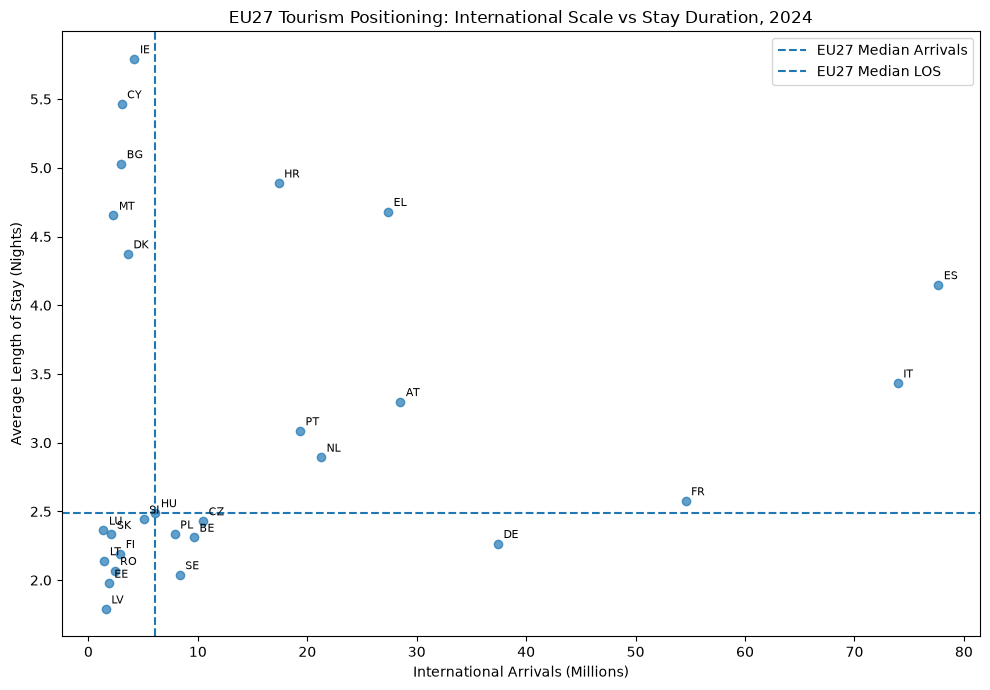

In [29]:
plt.figure(figsize=(10, 7))

plt.scatter(
    benchmark_2024["foreign_arrivals"] / 1_000_000,
    benchmark_2024["avg_length_of_stay"],
    alpha=0.7
)

plt.axvline(
    median_arrivals_2024 / 1_000_000,
    linestyle="--",
    label="EU27 Median Arrivals"
)

plt.axhline(
    median_los_2024,
    linestyle="--",
    label="EU27 Median LOS"
)

for _, row in benchmark_2024.iterrows():
    plt.annotate(
        row["country_code"],
        (
            row["foreign_arrivals"] / 1_000_000,
            row["avg_length_of_stay"]
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel(
    "International Arrivals (Millions)"
)

plt.ylabel(
    "Average Length of Stay (Nights)"
)

plt.title(
    "EU27 Tourism Positioning: "
    "International Scale vs Stay Duration, 2024"
)

plt.legend()

plt.tight_layout()
plt.show()

In [30]:
germany_rank_history = (
    germany_arrivals_rank[
        [
            "year",
            "arrivals_rank",
            "countries_compared"
        ]
    ]
    .rename(
        columns={
            "countries_compared":
            "arrival_countries_compared"
        }
    )
    .merge(
        germany_nights_rank[
            [
                "year",
                "nights_rank",
                "countries_compared"
            ]
        ].rename(
            columns={
                "countries_compared":
                "night_countries_compared"
            }
        ),
        on="year",
        how="inner",
        validate="one_to_one"
    )
)

germany_rank_history[
    "rank_gap"
] = (
    germany_rank_history[
        "nights_rank"
    ]
    - germany_rank_history[
        "arrivals_rank"
    ]
)

display(
    germany_rank_history
)

,year,arrivals_rank,arrival_countries_compared,nights_rank,night_countries_compared,rank_gap
0,2021,4,22,7,25,3
1,2022,4,24,7,25,3
2,2023,4,24,7,25,3
3,2024,4,27,7,27,3
4,2025,4,26,7,27,3


In [31]:
annual_benchmark = (
    annual_arrivals[
        [
            "country_code",
            "country",
            "year",
            "foreign_arrivals"
        ]
    ]
    .merge(
        annual_nights[
            [
                "country_code",
                "year",
                "foreign_nights"
            ]
        ],
        on=[
            "country_code",
            "year"
        ],
        how="inner",
        validate="one_to_one"
    )
)

annual_benchmark[
    "avg_length_of_stay"
] = (
    annual_benchmark[
        "foreign_nights"
    ]
    / annual_benchmark[
        "foreign_arrivals"
    ]
)

annual_benchmark[
    "los_rank"
] = (
    annual_benchmark.groupby(
        "year"
    )["avg_length_of_stay"]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

annual_benchmark[
    "countries_compared"
] = (
    annual_benchmark.groupby(
        "year"
    )["country_code"]
    .transform("nunique")
)

print(
    "Countries with complete arrivals "
    "and nights:"
)

print(
    annual_benchmark.groupby(
        "year"
    )["country_code"].nunique()
)

Countries with complete arrivals and nights:
year
2021    22
2022    24
2023    24
2024    27
2025    26
Name: country_code, dtype: int64


In [32]:
germany_los_history = (
    annual_benchmark[
        annual_benchmark[
            "country_code"
        ] == "DE"
    ][
        [
            "year",
            "foreign_arrivals",
            "foreign_nights",
            "avg_length_of_stay",
            "los_rank",
            "countries_compared"
        ]
    ]
    .reset_index(
        drop=True
    )
)

display(
    germany_los_history
)

,year,foreign_arrivals,foreign_nights,avg_length_of_stay,los_rank,countries_compared
0,2021,11657007.0,30731500.0,2.636311,13,22
1,2022,28382919.0,67616302.0,2.382289,17,24
2,2023,34711761.0,80378429.0,2.315596,20,24
3,2024,37419799.0,84792636.0,2.265983,21,27
4,2025,37134349.0,83075445.0,2.237159,21,26


In [33]:
eu_los_history = (
    annual_benchmark.groupby(
        "year"
    )
    .agg(
        countries_compared=(
            "country_code",
            "nunique"
        ),
        eu_mean_los=(
            "avg_length_of_stay",
            "mean"
        ),
        eu_median_los=(
            "avg_length_of_stay",
            "median"
        ),
        total_arrivals=(
            "foreign_arrivals",
            "sum"
        ),
        total_nights=(
            "foreign_nights",
            "sum"
        )
    )
    .reset_index()
)

eu_los_history[
    "eu_weighted_los"
] = (
    eu_los_history[
        "total_nights"
    ]
    / eu_los_history[
        "total_arrivals"
    ]
)

display(
    eu_los_history[
        [
            "year",
            "countries_compared",
            "eu_mean_los",
            "eu_median_los",
            "eu_weighted_los"
        ]
    ].round(2)
)

,year,countries_compared,eu_mean_los,eu_median_los,eu_weighted_los
0,2021,22,3.50,2.78,3.94
1,2022,24,3.26,2.64,3.51
2,2023,24,3.26,2.59,3.38
3,2024,27,3.17,2.49,3.34
4,2025,26,3.09,2.50,3.31


In [35]:
germany_eu_los_gap = (
    germany_los_history[
        [
            "year",
            "avg_length_of_stay",
            "los_rank",
            "countries_compared"
        ]
    ]
    .merge(
        eu_los_history[
            [
                "year",
                "eu_mean_los",
                "eu_median_los",
                "eu_weighted_los"
            ]
        ],
        on="year",
        how="left",
        validate="one_to_one"
    )
)

germany_eu_los_gap[
    "gap_vs_mean"
] = (
    germany_eu_los_gap[
        "avg_length_of_stay"
    ]
    - germany_eu_los_gap[
        "eu_mean_los"
    ]
)

germany_eu_los_gap[
    "gap_vs_median"
] = (
    germany_eu_los_gap[
        "avg_length_of_stay"
    ]
    - germany_eu_los_gap[
        "eu_median_los"
    ]
)

germany_eu_los_gap[
    "gap_vs_weighted"
] = (
    germany_eu_los_gap[
        "avg_length_of_stay"
    ]
    - germany_eu_los_gap[
        "eu_weighted_los"
    ]
)

display(
    germany_eu_los_gap.round(3)
)

,year,avg_length_of_stay,los_rank,countries_compared,eu_mean_los,eu_median_los,eu_weighted_los,gap_vs_mean,gap_vs_median,gap_vs_weighted
0,2021,2.636,13,22,3.501,2.784,3.942,-0.864,-0.148,-1.305
1,2022,2.382,17,24,3.258,2.636,3.511,-0.876,-0.253,-1.128
2,2023,2.316,20,24,3.264,2.585,3.380,-0.949,-0.270,-1.064
3,2024,2.266,21,27,3.167,2.490,3.340,-0.901,-0.224,-1.074
4,2025,2.237,21,26,3.090,2.497,3.311,-0.853,-0.259,-1.073


In [36]:
comparison_change = pd.DataFrame(
    {
        "indicator": [
            "Germany LOS",
            "EU Mean LOS",
            "EU Median LOS",
            "EU Weighted LOS"
        ],
        "value_2021": [
            germany_eu_los_gap.loc[
                germany_eu_los_gap["year"] == 2021,
                "avg_length_of_stay"
            ].iloc[0],

            germany_eu_los_gap.loc[
                germany_eu_los_gap["year"] == 2021,
                "eu_mean_los"
            ].iloc[0],

            germany_eu_los_gap.loc[
                germany_eu_los_gap["year"] == 2021,
                "eu_median_los"
            ].iloc[0],

            germany_eu_los_gap.loc[
                germany_eu_los_gap["year"] == 2021,
                "eu_weighted_los"
            ].iloc[0]
        ],
        "value_2025": [
            germany_eu_los_gap.loc[
                germany_eu_los_gap["year"] == 2025,
                "avg_length_of_stay"
            ].iloc[0],

            germany_eu_los_gap.loc[
                germany_eu_los_gap["year"] == 2025,
                "eu_mean_los"
            ].iloc[0],

            germany_eu_los_gap.loc[
                germany_eu_los_gap["year"] == 2025,
                "eu_median_los"
            ].iloc[0],

            germany_eu_los_gap.loc[
                germany_eu_los_gap["year"] == 2025,
                "eu_weighted_los"
            ].iloc[0]
        ]
    }
)

comparison_change[
    "absolute_change"
] = (
    comparison_change[
        "value_2025"
    ]
    - comparison_change[
        "value_2021"
    ]
)

comparison_change[
    "percent_change"
] = (
    comparison_change[
        "absolute_change"
    ]
    / comparison_change[
        "value_2021"
    ]
    * 100
)

display(
    comparison_change.round(3)
)

,indicator,value_2021,value_2025,absolute_change,percent_change
0,Germany LOS,2.636,2.237,-0.399,-15.141
1,EU Mean LOS,3.501,3.090,-0.411,-11.734
2,EU Median LOS,2.784,2.497,-0.288,-10.341
3,EU Weighted LOS,3.942,3.311,-0.631,-16.011


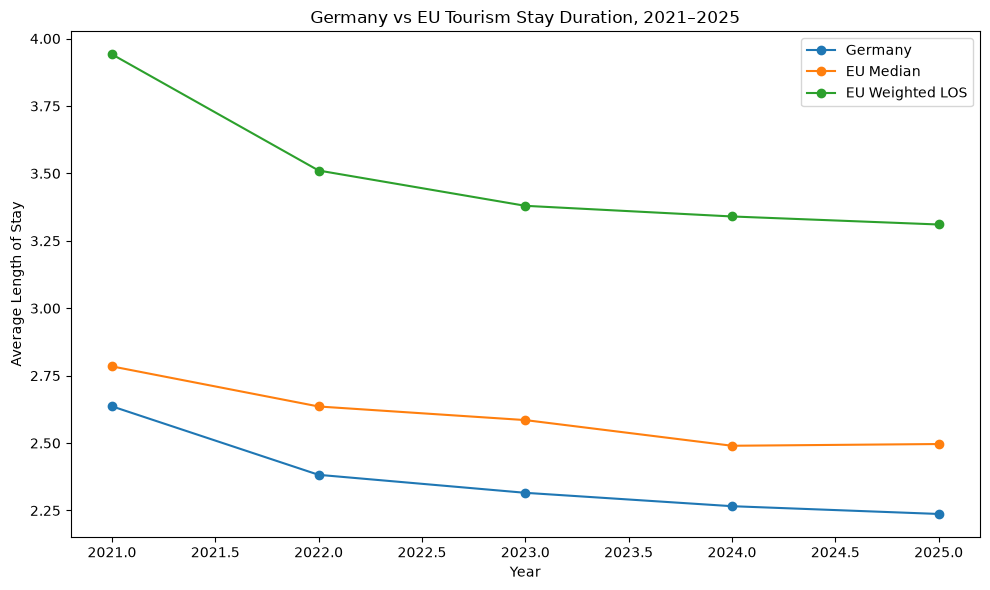

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(
    germany_eu_los_gap["year"],
    germany_eu_los_gap[
        "avg_length_of_stay"
    ],
    marker="o",
    label="Germany"
)

plt.plot(
    germany_eu_los_gap["year"],
    germany_eu_los_gap[
        "eu_median_los"
    ],
    marker="o",
    label="EU Median"
)

plt.plot(
    germany_eu_los_gap["year"],
    germany_eu_los_gap[
        "eu_weighted_los"
    ],
    marker="o",
    label="EU Weighted LOS"
)

plt.xlabel("Year")
plt.ylabel("Average Length of Stay")

plt.title(
    "Germany vs EU Tourism Stay Duration, 2021–2025"
)

plt.legend()
plt.tight_layout()
plt.show()

### Competitive Position Over Time

Germany maintained a stable position in international tourism volume across the available complete-country comparisons from 2021 to 2025, ranking fourth in international arrivals and seventh in international overnight stays in each year.

Average length of stay, however, declined from approximately 2.64 nights in 2021 to 2.24 nights in 2025, representing a decrease of approximately 15.14%.

This decline was not unique to Germany. Over the same period, the unweighted EU comparison mean declined by approximately 11.73%, the median by 10.34%, and the weighted EU average by 16.01%.

Germany therefore experienced its decline within a broader European pattern of shorter international stays.

The relative benchmark picture is more nuanced. Germany's gap to the unweighted EU mean remained broadly stable, moving from approximately 0.86 nights below the mean in 2021 to 0.85 nights below it in 2025. Its gap to the weighted EU benchmark narrowed from approximately 1.31 nights to 1.07 nights.

In contrast, Germany's gap to the EU median widened from approximately 0.15 nights in 2021 to 0.26 nights in 2025.

Germany's relative LOS ranking also deteriorated, moving from 13th among 22 comparable countries in 2021 to 21st among 26 comparable countries in 2025. Historical ranks should be interpreted cautiously because the number of countries with complete comparable data differs by year.

Overall, the evidence does not indicate a simple widening of Germany's length-of-stay gap against every EU benchmark. Instead, Germany experienced a substantial decline in stay duration within a broader European decline while remaining comparatively weak in tourism stay depth.

This distinction is important: Germany's competitive challenge is not simply that average stays are falling, but that its already high international arrival volume continues to translate into comparatively short stays.

In [38]:
gap_change_summary = pd.DataFrame(
    {
        "benchmark": [
            "EU Mean",
            "EU Median",
            "EU Weighted"
        ],
        "gap_2021": [
            germany_eu_los_gap.loc[
                germany_eu_los_gap["year"] == 2021,
                "gap_vs_mean"
            ].iloc[0],

            germany_eu_los_gap.loc[
                germany_eu_los_gap["year"] == 2021,
                "gap_vs_median"
            ].iloc[0],

            germany_eu_los_gap.loc[
                germany_eu_los_gap["year"] == 2021,
                "gap_vs_weighted"
            ].iloc[0]
        ],
        "gap_2025": [
            germany_eu_los_gap.loc[
                germany_eu_los_gap["year"] == 2025,
                "gap_vs_mean"
            ].iloc[0],

            germany_eu_los_gap.loc[
                germany_eu_los_gap["year"] == 2025,
                "gap_vs_median"
            ].iloc[0],

            germany_eu_los_gap.loc[
                germany_eu_los_gap["year"] == 2025,
                "gap_vs_weighted"
            ].iloc[0]
        ]
    }
)

gap_change_summary[
    "gap_change"
] = (
    gap_change_summary["gap_2025"]
    - gap_change_summary["gap_2021"]
)

gap_change_summary[
    "interpretation"
] = np.where(
    gap_change_summary["gap_change"] > 0,
    "Gap Narrowed",
    "Gap Widened"
)

display(
    gap_change_summary.round(3)
)

,benchmark,gap_2021,gap_2025,gap_change,interpretation
0,EU Mean,-0.864,-0.853,0.012,Gap Narrowed
1,EU Median,-0.148,-0.259,-0.111,Gap Widened
2,EU Weighted,-1.305,-1.073,0.232,Gap Narrowed


In [39]:
annual_arrivals[
    "leader_arrivals"
] = (
    annual_arrivals.groupby(
        "year"
    )["foreign_arrivals"]
    .transform("max")
)

annual_arrivals[
    "share_of_arrivals_leader_pct"
] = (
    annual_arrivals["foreign_arrivals"]
    / annual_arrivals["leader_arrivals"]
    * 100
)

annual_nights[
    "leader_nights"
] = (
    annual_nights.groupby(
        "year"
    )["foreign_nights"]
    .transform("max")
)

annual_nights[
    "share_of_nights_leader_pct"
] = (
    annual_nights["foreign_nights"]
    / annual_nights["leader_nights"]
    * 100
)

germany_leader_gap = (
    annual_arrivals[
        annual_arrivals["country_code"] == "DE"
    ][
        [
            "year",
            "foreign_arrivals",
            "leader_arrivals",
            "share_of_arrivals_leader_pct"
        ]
    ]
    .merge(
        annual_nights[
            annual_nights["country_code"] == "DE"
        ][
            [
                "year",
                "foreign_nights",
                "leader_nights",
                "share_of_nights_leader_pct"
            ]
        ],
        on="year",
        how="inner",
        validate="one_to_one"
    )
)

display(
    germany_leader_gap.round(2)
)

,year,foreign_arrivals,leader_arrivals,share_of_arrivals_leader_pct,foreign_nights,leader_nights,share_of_nights_leader_pct
0,2021,11657007.0,26903217.0,43.33,30731500.0,114345133.0,26.88
1,2022,28382919.0,62470426.0,45.43,67616302.0,271440906.0,24.91
2,2023,34711761.0,72140442.0,48.12,80378429.0,301927202.0,26.62
3,2024,37419799.0,77654281.0,48.19,84792636.0,322195966.0,26.32
4,2025,37134349.0,87897260.0,42.25,83075445.0,328928185.0,25.26


## Germany–EU Benchmark Summary

The EU27 benchmark reveals a clear distinction between Germany's ability to attract international visitors and its ability to generate overnight stays from those visitors.

### 1. Germany is a major EU tourism destination by visitor volume

Germany maintained fourth position in international arrivals across the available complete-country comparisons from 2021 to 2025.

In 2024, the only year in the analysis with complete arrivals and overnight-stay data for all 27 EU countries, Germany recorded approximately 37.42 million international arrivals and ranked fourth in the EU27.

Only Spain, Italy, and France recorded more international arrivals.

### 2. Germany's overnight-stay position is weaker than its arrivals position

Germany ranked seventh in international overnight stays across the available annual comparisons.

In 2024, Germany generated approximately 84.79 million international overnight stays, placing it seventh among all 27 EU countries.

Germany was therefore three ranking positions lower in overnight stays than in arrivals.

The difference indicates that Germany's strong visitor volume does not translate proportionally into overnight-stay volume.

### 3. Short average stays are a principal competitive gap

Germany's international average length of stay was approximately 2.27 nights in 2024, ranking 21st among the 27 EU countries.

This was below:

- the EU27 median of approximately 2.49 nights
- the unweighted EU27 mean of approximately 3.17 nights
- the weighted EU27 average of approximately 3.34 nights

Germany was also positioned slightly below the first quartile of the EU27 length-of-stay distribution.

The competitive-position analysis therefore classified Germany as a **High Scale / Shorter Stay** destination.

### 4. Several major competitors combine scale with longer stays

Spain, Italy, France, Austria, Greece, the Netherlands, Portugal, and Croatia combined above-median international arrival volume with above-median average stay duration in 2024.

Austria provides a particularly useful benchmark. Despite receiving fewer international arrivals than Germany, Austria generated more international overnight stays because its average length of stay was substantially higher.

This demonstrates the importance of evaluating tourism depth alongside visitor volume.

### 5. Benchmark scenarios illustrate the scale of the stay-duration gap

At Germany's actual 2024 international arrival volume:

- the EU27 median LOS corresponds mathematically to approximately 8.39 million additional overnight stays
- France's LOS corresponds to approximately 11.64 million additional nights
- the Netherlands' LOS corresponds to approximately 23.51 million additional nights
- Austria's LOS corresponds to approximately 38.64 million additional nights
- the weighted EU27 LOS corresponds to approximately 40.20 million additional nights

These are illustrative counterfactual benchmarks rather than forecasts. They do not imply that these additional overnight stays are fully achievable or recoverable.

### 6. Germany was very close to sixth position in overnight stays in 2024

Germany recorded only approximately 163,000 fewer international overnight stays than Croatia in 2024, a difference of approximately 0.19%.

Holding Germany's arrival volume constant, this difference corresponds mathematically to only a very small change in average stay duration.

This illustrates how close Germany was to sixth position, but it should not be treated as an operational tourism target because competitor performance is not fixed.

### 7. Declining stay duration is partly a broader European pattern

Germany's average length of stay declined by approximately 15.14% between 2021 and 2025.

However, EU benchmarks also declined:

- unweighted EU comparison mean: approximately 11.73%
- EU median: approximately 10.34%
- weighted EU average: approximately 16.01%

Germany's decline should therefore not be interpreted as an isolated national phenomenon.

Its gap to the EU mean remained broadly stable, its gap to the weighted benchmark narrowed, while its gap to the median widened.

At the same time, Germany's LOS ranking deteriorated from 13th among 22 comparable countries in 2021 to 21st among 26 comparable countries in 2025.

### 8. Stable rankings can conceal changes in competitive distance

Germany remained fourth in arrivals and seventh in overnight stays, but its distance from the annual tourism-volume leader changed over time.

In 2024, Germany's international arrivals were approximately 48.19% of the leader's volume and its overnight stays approximately 26.32% of the leader's volume.

In 2025, these ratios were approximately 42.25% and 25.26%, respectively.

Historical comparisons should be interpreted cautiously because country coverage differs across years. The 2024 results provide the strongest full-EU27 benchmark because all 27 countries have complete comparable data.

### Overall Competitive Interpretation

Germany demonstrates strong international tourism scale but comparatively weak tourism depth.

Its principal competitive challenge is not simply attracting more international visitors. Germany already ranks among the EU's largest destinations by arrivals.

The more distinctive gap is the comparatively short duration of international stays, which limits the number of overnight stays generated from Germany's substantial visitor base.

This finding supports a strategic distinction between **visitor acquisition** and **visitor value or tourism depth**. Subsequent analysis should therefore examine which source markets combine scale, growth, and longer stay duration and may offer stronger opportunities for improving Germany's international tourism performance.

In [40]:
benchmark_2024.to_csv(
    processed_dir
    / "eu27_tourism_benchmark_2024.csv",
    index=False
)

annual_benchmark.to_csv(
    processed_dir
    / "eu27_tourism_benchmark_annual.csv",
    index=False
)

germany_eu_los_gap.to_csv(
    processed_dir
    / "germany_eu_los_benchmark_2021_2025.csv",
    index=False
)

los_scenarios.to_csv(
    processed_dir
    / "germany_los_counterfactual_scenarios_2024.csv",
    index=False
)

germany_leader_gap.to_csv(
    processed_dir
    / "germany_eu_leader_gap_2021_2025.csv",
    index=False
)

gap_change_summary.to_csv(
    processed_dir
    / "germany_los_gap_change_summary.csv",
    index=False
)

print(
    "Germany-EU benchmark outputs "
    "saved successfully."
)

Germany-EU benchmark outputs saved successfully.


In [41]:
sorted(
    file.name
    for file in processed_dir.glob("*.csv")
)

['eu27_tourism_benchmark_2024.csv',
 'eu27_tourism_benchmark_annual.csv',
 'germany_eu_leader_gap_2021_2025.csv',
 'germany_eu_los_benchmark_2021_2025.csv',
 'germany_los_counterfactual_scenarios_2024.csv',
 'germany_los_gap_change_summary.csv']